In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA, FastICA
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import power_transform
from scipy import signal


import lissa as li

In [3]:
np.random.seed(1)

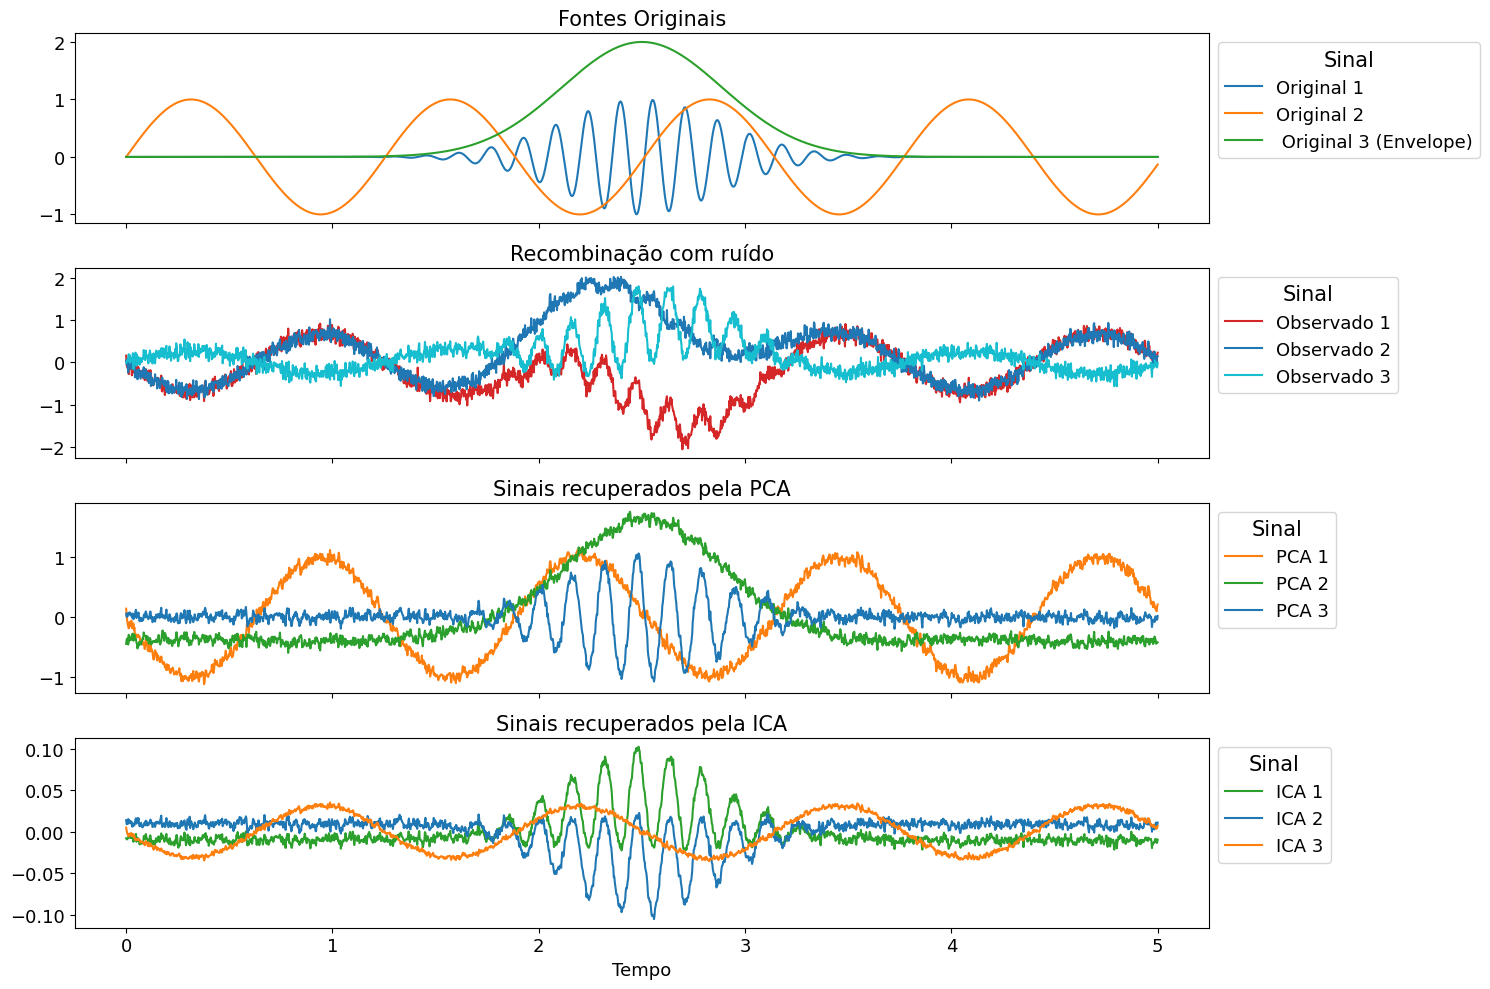

In [4]:
n = 2000
tf = 5
t = np.linspace(0,tf,n)

window = np.exp((-(t-tf/2)*(t-tf/2))/0.3)

X = np.array(
    [
        np.sin(40*t)*window,
        #np.sin(10*t+np.pi/4)*window,
        np.sin(5*t),
        2*np.ones(n)*window
    ]
)

nc = X.shape[0]


noiseamp = 0.05*np.max(X)
noise = noiseamp*np.random.randn(nc,n)


Q = np.linalg.qr(np.random.rand(nc,nc)).Q


S = pd.DataFrame(X.T@Q,columns=["Observado 1","Observado 2","Observado 3"],index=t)#,"Recombinação 3"])
Sn = (S+noise.T)
Z = Sn.ewm(alpha=0.5).mean()#((S-S.expanding().mean())/S.expanding().std()).fillna(0)

#Z.plot()

modelPCA = PCA(n_components=nc)
recoverPCA = pd.DataFrame(modelPCA.fit_transform(Z),columns=["PCA 1","PCA 2","PCA 3"],index=t)#,"PCA 3"])


modelICA = FastICA(n_components=nc,whiten="arbitrary-variance")
recoverICA = pd.DataFrame(modelICA.fit_transform(Z),columns=["ICA 1","ICA 2","ICA 3"],index=t)#,"ICA 3"])

fig, axs = plt.subplots(4,1,sharex=True)
#plt.rcParams.update({'font.size': 20})

pd.DataFrame(X.T,columns=["Original 1","Original 2"," Original 3 (Envelope)"],index=t).plot(ax=axs[0],fontsize=13, color = ["tab:blue","tab:orange","tab:green"]) #,"Original 3"

Sn.plot(ax=axs[1],figsize=(15,10),fontsize=13,color = ["tab:red","tab:blue","tab:cyan"])

recoverPCA.plot(ax=axs[2],fontsize=13,color = ["tab:orange","tab:green","tab:blue"])
recoverICA.plot(ax=axs[3],fontsize=13,color = ["tab:green","tab:blue","tab:orange"])

titulos = ["Fontes Originais","Recombinação com ruído","Sinais recuperados pela PCA","Sinais recuperados pela ICA"]

for i in range(0,4):
    axs[i].set_title(titulos[i],fontsize=15)


for i in range(0,4):
    axs[i].legend(title="Sinal",loc='upper left',bbox_to_anchor=(1, 1),fontsize=13,title_fontsize=15)

axs[3].set_xlabel("Tempo",fontsize=13)
plt.tight_layout()
fig.savefig("./imagens_exemplos/PCA_exemplo")


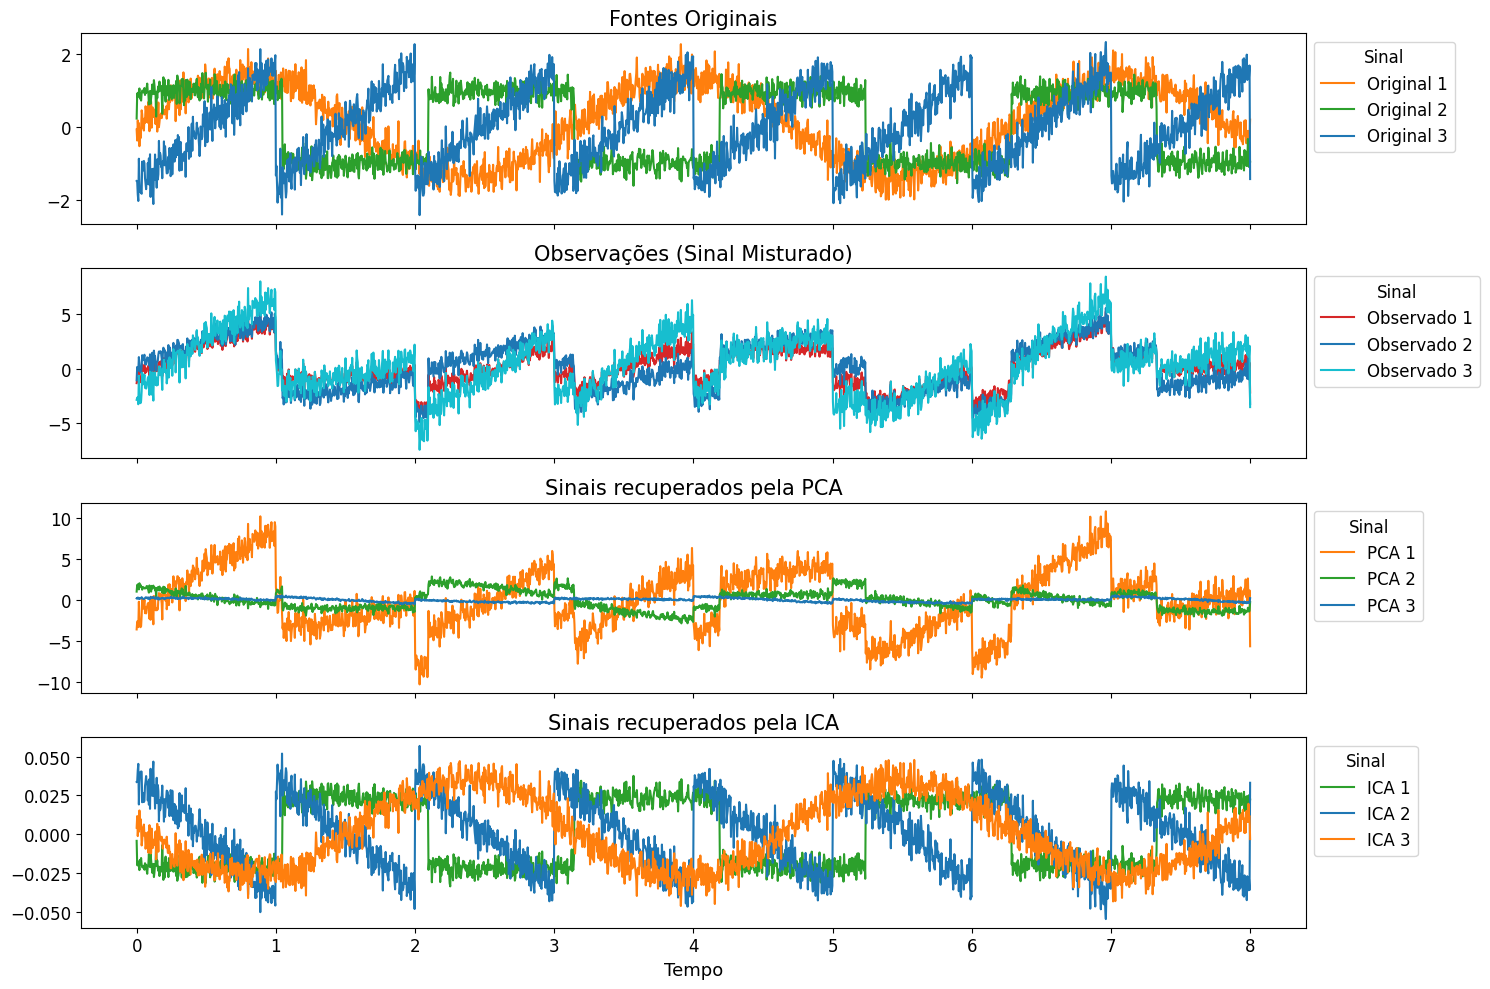

In [5]:
np.random.seed(19640822)
n_samples = 2000
time = np.linspace(0, 8, n_samples)

s1 = np.sin(2 * time)  # Signal 1 : sinusoidal signal
s2 = np.sign(np.sin(3 * time))  # Signal 2 : square signal
s3 = signal.sawtooth(2 * np.pi * time)  # Signal 3: saw tooth signal

S = np.c_[s1, s2, s3]
S += 0.2 * np.random.normal(size=S.shape)  # Add noise

S /= S.std(axis=0)  # Standardize data
# Mix data
A = np.array([[1, 1, 1], [0.5, 2, 1.0], [1.5, 1.0, 2.0]])  # Mixing matrix
X = np.dot(S, A.T)  # Generate observations


# Compute ICA
ica = FastICA(n_components=3, whiten="arbitrary-variance")
S_ = ica.fit_transform(X)  # Reconstruct signals
A_ = ica.mixing_  # Get estimated mixing matrix

# We can `prove` that the ICA model applies by reverting the unmixing.
assert np.allclose(X, np.dot(S_, A_.T) + ica.mean_)

# For comparison, compute PCA
pca = PCA(n_components=3)
H = pca.fit_transform(X)  # Reconstruct signals based on orthogonal components


fig,axs = plt.subplots(4,1,figsize=(15,10),sharex=True)

X = pd.DataFrame(X,columns=["Observado 1","Observado 2","Observado 3"],index=time)
S = pd.DataFrame(S,columns=["Original 1","Original 2","Original 3"],index=time)
S_ = pd.DataFrame(S_,columns=["ICA 1","ICA 2","ICA 3"],index=time)
H = pd.DataFrame(H,columns=["PCA 1","PCA 2","PCA 3"],index=time)

models = [S, X, H, S_]
names = [
    "Fontes Originais",
    "Observações (Sinal Misturado)",
    "Sinais recuperados pela PCA",
    "Sinais recuperados pela ICA"
]

colors = {
    "Fontes Originais":["tab:orange","tab:green","tab:blue"],
    "Observações (Sinal Misturado)":["tab:red","tab:blue","tab:cyan"],
    "Sinais recuperados pela PCA":["tab:orange","tab:green","tab:blue"],
    "Sinais recuperados pela ICA":["tab:green","tab:blue","tab:orange"]
}

i = 0
for i,(model, name) in enumerate(zip(models, names), 0):
    model.plot(ax=axs[i],fontsize=11,color = colors[name])
    axs[i].legend(title="Sinal", loc='upper left',bbox_to_anchor=(1, 1),title_fontsize=12, fontsize=12)
    axs[i].set_title(name,fontsize=15)
    axs[i].tick_params(labelsize=12)


    # for sig, color in zip(model.T, colors):
    #     axs[i].plot(sig, color=color)
    #     axs[i].set_title(name,fontsize=15)
    #     
axs[3].set_xlabel("Tempo",fontsize=13)
plt.tight_layout()
fig.savefig("./imagens_exemplos/ICA_exemplo")

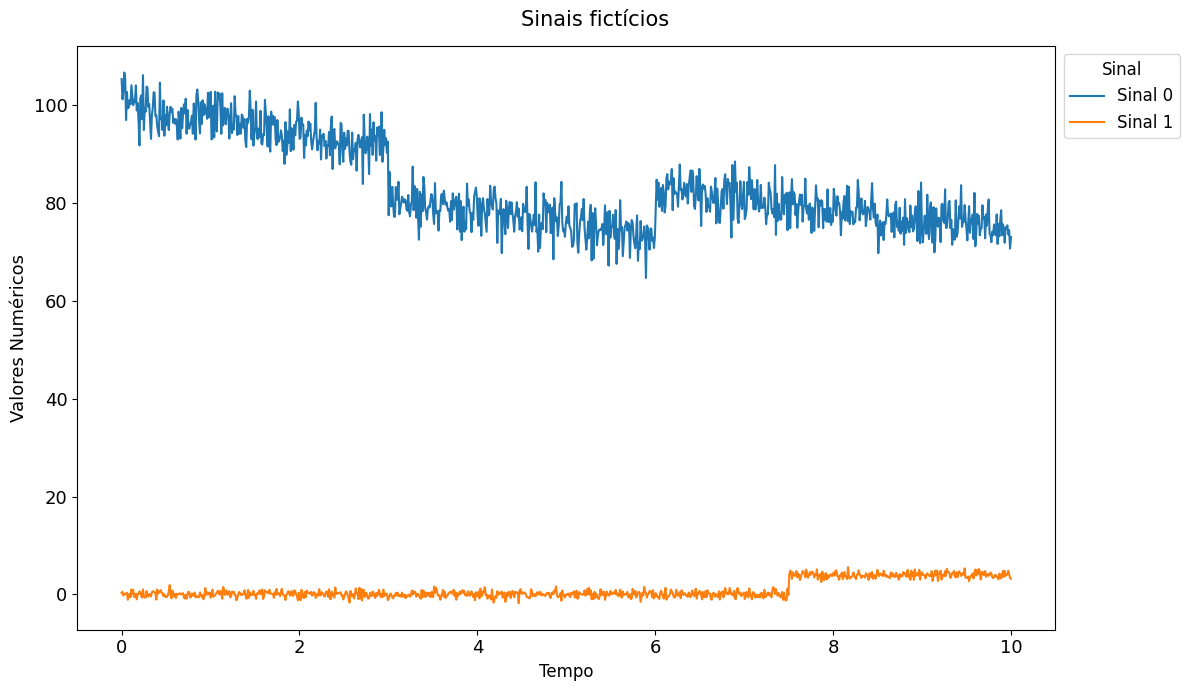

In [6]:
n = 1000
tf = 10
t = np.linspace(0,tf,n)

window = np.exp((-(t-tf/2)*(t-tf/2))/0.1)

np.random.seed(0)

noiseAmp = 0.03
decay = -0.03

windowAmp = 0.2
VA1 = 100
VA2 = 20

# V1 = VA1*((windowAmp*window)+np.exp(decay*t)+noiseAmp*np.random.randn(n))
# V2 = VA2*((windowAmp*window)+np.exp(decay*t)+noiseAmp*np.random.randn(n))
#V2 = np.random.randn(n)*np.exp(0.04*t)

V1 = VA1*(np.exp(decay*t)+noiseAmp*np.random.randn(n))
V2 = VA2*(noiseAmp*np.random.randn(n))
#V1[int(np.floor(1*n/4)):int(np.floor(3*n/4))]+=10 

V2[int(np.floor(3*n/4)):]+=VA2/5

V1[int(np.floor(3*n/10)):int(np.floor(6*n/10))]-=VA1/10
#V2[125:375]-=3

#V = pd.DataFrame(V1,index=t,columns=["Sinal 0"])
V = pd.DataFrame(np.array([V1, V2]).T,columns=["Sinal 0","Sinal 1"],index=t)
#np.concatenate(np.zeros((2,250)),2*np.ones((250,2)))



fig,axs = plt.subplots(1,1,figsize=(12,7))
V.plot(ax=axs,fontsize=13)
axs.legend(title="Sinal", loc='upper left',bbox_to_anchor=(1, 1),title_fontsize=12, fontsize=12)
fig.suptitle("Sinais fictícios",fontsize=15)
plt.tight_layout()
axs.set_xlabel("Tempo",fontsize=12)
axs.set_ylabel("Valores Numéricos",fontsize=13)
plt.tight_layout()
fig.savefig("./imagens_exemplos/sinal_simulado")

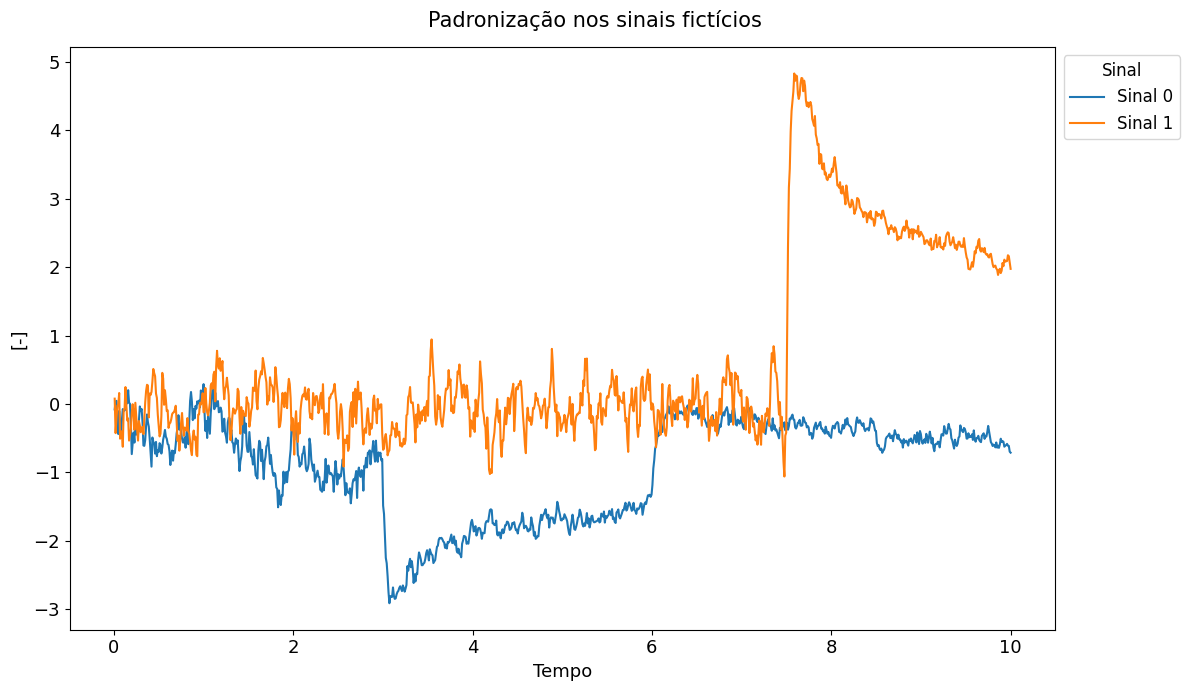

In [7]:
Z = ((V.ewm(alpha=0.2).mean()-V.expanding().median())/V.expanding().std())

fig,axs = plt.subplots(1,1,figsize=(12,7))
Z.plot(ax=axs,fontsize=13)
axs.legend(title="Sinal", loc='upper left',bbox_to_anchor=(1, 1),title_fontsize=12, fontsize=12)
fig.suptitle("Padronização nos sinais fictícios",fontsize=15)
axs.set_xlabel("Tempo",fontsize=13)
axs.set_ylabel("[-]",fontsize=13)
plt.tight_layout()
fig.savefig("./imagens_exemplos/padronização")

GMM AIC: 2645.009471411615
GMM BIC: 2669.5482478065255


<Figure size 640x480 with 0 Axes>

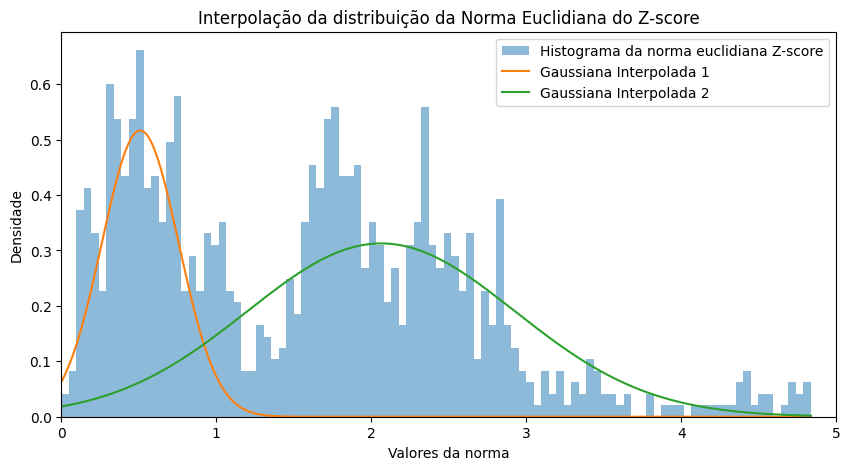

(GaussianMixture(n_components=2), <Figure size 1000x500 with 1 Axes>)

In [8]:

#Z.hist(bins=20)#.pow(2).sum(axis=1).pow(1/2).hist(bins=20)

squared = Z.pow(2).sum(axis=1).pow(1/2)
plt.figure()

n = 2

model = li.GaussianMixtureFit(squared,n,seed=np.random.seed(0))
squared.name = "Squared"

li.GaussianMixturePlot(squared,model,[
    "Histograma da norma euclidiana Z-score",
    "Gaussiana Interpolada",
    "Interpolação da distribuição da Norma Euclidiana do Z-score",
    "Valores da norma",
    "Densidade"],
    figsize=(10,5),limits=(0,5),path="./imagens_exemplos/")


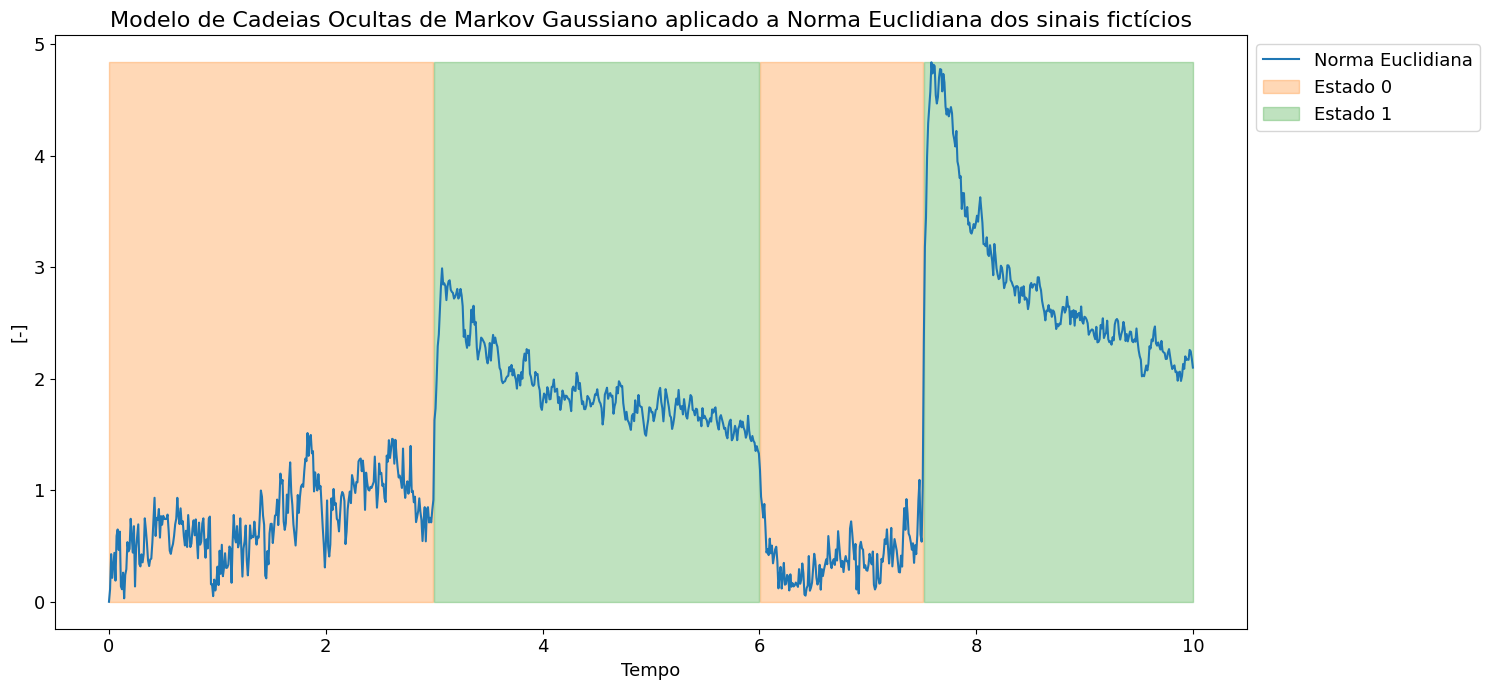

In [9]:

# Exemplo de estados ao longo do tempo
states = range(0,n)

# Gerando cores automáticas com base no número de estados
num_states = len(np.unique(states))
cmap = plt.get_cmap('tab10', num_states)  # Escolhe um colormap com num_states cores

cmap = ["tab:orange","tab:green"]

model = GaussianHMM(n_components=n,covariance_type="full",random_state=np.random.seed(0))
model.fit(squared.to_numpy().reshape(-1,1))

states = model.predict(squared.to_numpy().reshape(-1,1))

final = pd.DataFrame(np.array([squared, states]).T,columns=["Norma L2","STS"],index=t)

fig,axs = plt.subplots(1,1)
final["Norma L2"].plot(ax=axs,figsize=(15,7),fontsize=13,label="Norma Euclidiana")


for state in range(0,n):
            #color = cmap(state)  # Pega uma cor automática para cada estado
            axs.fill_between(final.index,np.min(squared), np.max(squared), where=(final["STS"] == state), 
                            color=cmap[state],#color,
                            alpha=0.3, label=f"Estado {state}")

            axs.legend(loc='upper left',bbox_to_anchor=(1, 1),fontsize=13)

plt.title("Modelo de Cadeias Ocultas de Markov Gaussiano aplicado a Norma Euclidiana dos sinais fictícios",fontsize=16)
axs.set_xlabel("Tempo",fontsize=13)
axs.set_ylabel("[-]",fontsize=13)
plt.tight_layout()
fig.savefig("./imagens_exemplos/ghmm_exemplo")



In [10]:
# k = 5

# dataPD = pd.DataFrame()
# for i in range(0,k):
#     dataPD[f"Square_{i}"] = data.shift(i)

# data2reg = dataPD.dropna(axis=0).shift(-1).dropna()
# y = data.shift(-k).dropna()

# A = data2reg.T@data2reg
# b = data2reg.T.to_numpy()@y

# np.linalg.solve(A,b)

In [11]:
# import numpy as np

# from sklearn.decomposition import PCA, FastICA

# rng = np.random.RandomState(42)
# S = rng.standard_t(1.5, size=(20000, 2))
# S[:, 0] *= 2.0

# # Mix data
# A = np.array([[1, 1], [0, 2]])  # Mixing matrix

# X = np.dot(S, A.T)  # Generate observations

# pca = PCA()
# S_pca_ = pca.fit(X).transform(X)

# ica = FastICA(random_state=rng, whiten="arbitrary-variance")
# S_ica_ = ica.fit(X).transform(X)  # Estimate the sources

# plt.figure(figsize=(15,5))
# plt.plot(S)

In [12]:
X

,Observado 1,Observado 2,Observado 3
0.000000,-1.326571,-1.061568,-2.847479
0.004002,-0.960767,0.147625,-2.655582
0.008004,-0.855848,-0.125183,-2.621991
0.012006,-1.174068,-0.185931,-3.250965
0.016008,0.168563,1.048580,-0.650526
...,...,...,...
7.983992,1.230150,0.953519,2.843962
7.987994,-0.026665,-0.489635,1.076267
7.991996,-0.031833,-0.975768,1.193265
7.995998,0.539991,-0.150241,2.076346


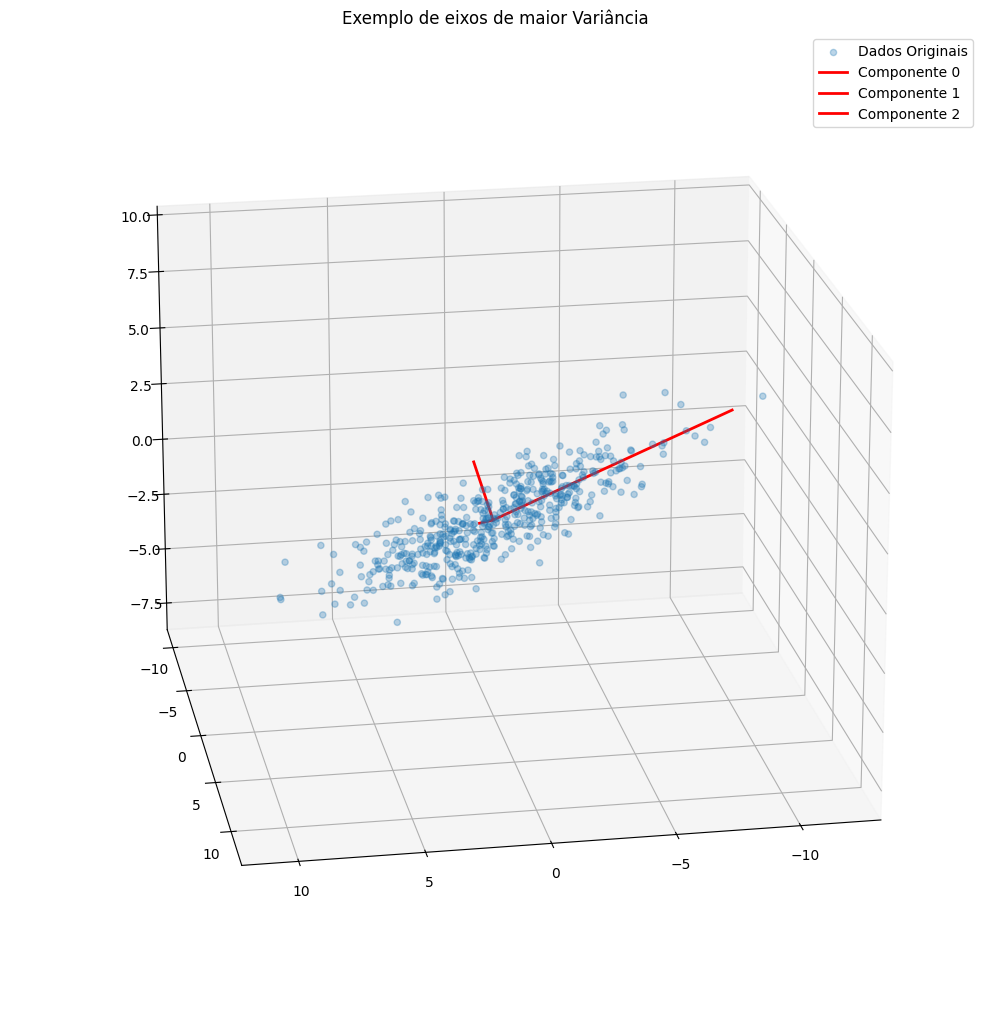

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Criar dados em forma de elipse (nuvem alongada)
np.random.seed(0)
X = np.random.randn(500, 3) @ np.array([[2, 0,0], [4, 1,0],[0, 0,1]]) @ np.array([[-1/np.sqrt(3), 1/np.sqrt(3),1/np.sqrt(3)], [0, 1,0],[0, 0,1]])  # alongado

# PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)

# Plot
fig = plt.figure(figsize=(10,30))
ax = fig.add_subplot(111,projection="3d")

ax.scatter(X[:,0], X[:,1],X[:,2], alpha=0.3,label="Dados Originais")
origin = np.mean(X, axis=0)

i = 0
for length, vector in zip(pca.explained_variance_, pca.components_):
    v = vector * 3 * np.sqrt(length)
    ax.plot([origin[0], origin[0]+v[0]], [origin[1], origin[1]+v[1]],[origin[2], origin[2]+v[2]], 'r-', lw=2,label=f"Componente {i}")
    i+=1


ax.view_init(elev=20, azim=80)
plt.legend()
plt.axis("equal")
plt.title("Exemplo de eixos de maior Variância")
plt.tight_layout()
plt.show()



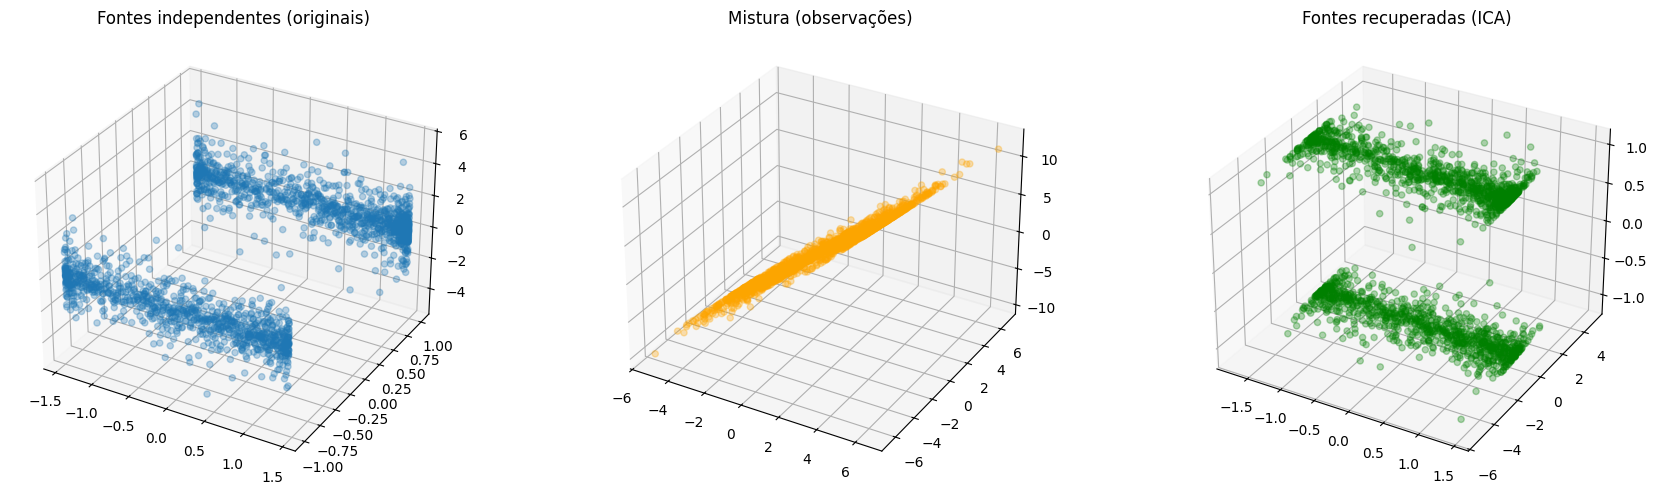

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import FastICA

# -----------------------
# 1. Criar sinais independentes (fontes)
# -----------------------
np.random.seed(0)
n_samples = 2000
time = np.linspace(0, 8, n_samples)

s1 = np.sin(2 * time)               # sinal senoidal
s2 = np.sign(np.sin(3 * time))      # onda quadrada
s3 = np.random.laplace(size=n_samples)  # ruído Laplaciano (não Gaussiano)

S = np.c_[s1, s2, s3]  # matriz (n_samples x 3)

# Normalizar
S /= S.std(axis=0)

# -----------------------
# 2. Mistura linear (como "observações")
# -----------------------
A = np.array([[1, 1, 1], [0.5, 2, 1.0], [1.5, 1.0, 2.0]])  # matriz de mistura
X = S @ A.T  # mistura observada (n_samples x 3)

# -----------------------
# 3. Aplicar ICA
# -----------------------
ica = FastICA(n_components=3, random_state=0)
S_ = ica.fit_transform(X)  # sinais reconstruídos
A_ = ica.mixing_           # matriz de mistura estimada

# -----------------------
# 4. Plotar em 3D
# -----------------------
fig = plt.figure(figsize=(18, 5))

# Fontes originais
ax = fig.add_subplot(131, projection="3d")
ax.scatter(S[:,0], S[:,1], S[:,2], alpha=0.3)
ax.set_title("Fontes independentes (originais)")

# Mistura observada
ax = fig.add_subplot(132, projection="3d")
ax.scatter(X[:,0], X[:,1], X[:,2], alpha=0.3, color="orange")
ax.set_title("Mistura (observações)")

# Fontes recuperadas por ICA
ax = fig.add_subplot(133, projection="3d")
ax.scatter(S_[:,0], S_[:,1], S_[:,2], alpha=0.3, color="green")
ax.set_title("Fontes recuperadas (ICA)")

plt.tight_layout()
plt.show()
